# Relationship Modeling — Copenhagen Networks Study

This notebook turns four exploratory questions about the Copenhagen Networks
Study into small, interpretable models:

1. **How do friends / friend groups form?** — a logistic regression that
   predicts Facebook friendship from interaction signals, plus community
   detection on the friendship graph.
2. **How do relationships evolve over the 4-week study?** — weekly
   interaction volume, with an honest discussion of why 4 weeks is a short
   window for per-pair trend detection.
3. **Who is most vs. least isolated?** — a composite centrality-based
   ranking over a combined interaction network.
4. **Does call duration trend upward over time?** — a linear regression of
   duration on timestamp.

**Data**: `data/raw/{calls,bt_symmetric,sms,fb_friends,genders}.csv`, the
Copenhagen Networks Study interaction data (~700+ university students, ~4-week
observation window). This notebook loads directly from the raw files, so it
does not depend on any other notebook having been run first.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# Shared styling: muted neutral grid/text + a fixed categorical hue order,
# so nothing here relies on a red/green good-bad cue.
plt.rcParams.update({
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "axes.grid": False,
    "figure.facecolor": "white",
    "font.size": 11,
})

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
CATEGORICAL = [BLUE, ORANGE, AQUA]
SECONDS_PER_DAY = 86_400

print("setup complete")

setup complete


In [2]:
calls_data = pd.read_csv('../data/raw/calls.csv')
bt_data = pd.read_csv('../data/raw/bt_symmetric.csv')
sms_data = pd.read_csv('../data/raw/sms.csv')
fb_data = pd.read_csv('../data/raw/fb_friends.csv')
genders_data = pd.read_csv('../data/raw/genders.csv')

# Raw files begin with a "# "-prefixed header for the first column; strip it
# (same fix used in cleaning.ipynb / eda_stat_summaires.ipynb).
bt_data = bt_data.rename(columns={bt_data.columns[0]: 'timestamp'})
fb_data = fb_data.rename(columns={fb_data.columns[0]: 'user_a'})
genders_data = genders_data.rename(columns={genders_data.columns[0]: 'user'})

# Sentinel / invalid-row cleaning (same rules established in cleaning.ipynb).
bt_valid = bt_data.loc[bt_data['user_b'].ge(0)].copy()                # drop empty scans (-1) and out-of-study devices (-2)
fb_data = fb_data.loc[fb_data['user_a'] != fb_data['user_b']].copy()  # drop self-friendship rows
completed_calls = calls_data.loc[calls_data['duration'].ge(0)].copy() # duration == -1 marks a missed call

print(f"Study span: {calls_data['timestamp'].max() / SECONDS_PER_DAY:.1f} days "
      f"({calls_data['timestamp'].max() / SECONDS_PER_DAY / 7:.2f} weeks) based on call timestamps")
print(f"Participants with a gender label: {genders_data['user'].nunique():,}")

Study span: 28.0 days (4.00 weeks) based on call timestamps
Participants with a gender label: 787


## 1. How friends and friend groups form

**Approach**: build one row per interacting pair of participants with
behavioral features (how often they were physically close, called, or
texted, and how many mutual Facebook friends they share), then fit a
**logistic regression** to predict whether that pair is Facebook-friends.
Logistic regression is the primary model here — not a more flexible one —
because its fitted coefficients are directly interpretable as "how much does
each behavior raise the odds of being friends," which is the actual
question. A random forest is fit alongside purely as an accuracy
cross-check on the same features, not as the explanatory model.

For *friend groups*, we run community detection (greedy modularity) directly
on the Facebook friendship graph — the densely connected clusters networkx
finds are our estimate of friend groups.

In [ ]:
pair_keys = ['user_a', 'user_b']

def make_undirected_pairs(df, left_col, right_col, extra_cols=None):
    """Return valid unordered (user_a < user_b) pairs, keeping any extra columns aligned."""
    columns = [left_col, right_col] + (extra_cols or [])
    pairs = df[columns].copy()
    left, right = pairs[left_col], pairs[right_col]
    pairs['user_a'] = pd.concat([left, right], axis=1).min(axis=1)
    pairs['user_b'] = pd.concat([left, right], axis=1).max(axis=1)
    return pairs.loc[pairs['user_a'].ge(0) & pairs['user_a'].lt(pairs['user_b'])]

bt_pairs = make_undirected_pairs(bt_valid, 'user_a', 'user_b', ['rssi', 'timestamp'])
sms_pairs = make_undirected_pairs(sms_data, 'sender', 'recipient', ['timestamp'])
call_pairs = make_undirected_pairs(calls_data, 'caller', 'callee', ['timestamp'])
fb_pairs = make_undirected_pairs(fb_data, 'user_a', 'user_b')[pair_keys].drop_duplicates()

# The pair universe includes FB-friend pairs even if they have no recorded
# proximity/call/SMS interaction, so "friends who never show up on any
# monitored channel" are represented as real negative-feature examples
# rather than silently excluded.
all_pairs = (
    pd.concat([bt_pairs[pair_keys], sms_pairs[pair_keys], call_pairs[pair_keys], fb_pairs], ignore_index=True)
    .drop_duplicates()
    .reset_index(drop=True)
)

bt_pair_features = bt_pairs.groupby(pair_keys).agg(
    proximity_count=('rssi', 'size'), mean_rssi=('rssi', 'mean')
).reset_index()
sms_pair_features = sms_pairs.groupby(pair_keys).size().rename('sms_count').reset_index()
call_pair_features = call_pairs.groupby(pair_keys).size().rename('call_count').reset_index()

# Undirected Facebook adjacency, used for both the friendship label and mutual-friend counts.
friend_neighbors = {}
for user_a, user_b in fb_pairs.itertuples(index=False):
    friend_neighbors.setdefault(user_a, set()).add(user_b)
    friend_neighbors.setdefault(user_b, set()).add(user_a)

pairwise = (
    all_pairs
    .merge(bt_pair_features, on=pair_keys, how='left')
    .merge(sms_pair_features, on=pair_keys, how='left')
    .merge(call_pair_features, on=pair_keys, how='left')
)

# Absence of interaction in a channel means zero, not missing.
for col in ['proximity_count', 'sms_count', 'call_count']:
    pairwise[col] = pairwise[col].fillna(0)
# A pair with no Bluetooth co-presence has no RSSI reading at all; fill with the
# sample mean so the (standardized) feature contributes ~0 rather than biasing a direction.
pairwise['mean_rssi'] = pairwise['mean_rssi'].fillna(pairwise['mean_rssi'].mean())

pairwise['mutual_friends'] = [
    len(friend_neighbors.get(a, set()) & friend_neighbors.get(b, set()))
    for a, b in pairwise[pair_keys].itertuples(index=False, name=None)
]
pairwise['is_fb_friend'] = [
    b in friend_neighbors.get(a, set())
    for a, b in pairwise[pair_keys].itertuples(index=False, name=None)
]

print(f"Pairs considered: {len(pairwise):,} | FB-friend pairs: {pairwise['is_fb_friend'].sum():,} "
      f"({pairwise['is_fb_friend'].mean():.1%})")
pairwise.head()


Pairs considered: 82,851 | FB-friend pairs: 6,418 (7.7%)


,user_a,user_b,proximity_count,mean_rssi,sms_count,call_count,mutual_friends,is_fb_friend
82846,510,827,0.0,-89.168558,0.0,0.0,11,True
82847,510,715,0.0,-89.168558,0.0,0.0,8,True
82848,510,737,0.0,-89.168558,0.0,0.0,9,True
82849,510,763,0.0,-89.168558,0.0,0.0,10,True
82850,255,507,0.0,-89.168558,0.0,0.0,0,True


In [19]:
feature_cols = ['proximity_count', 'mean_rssi', 'sms_count', 'call_count', 'mutual_friends']
X = pairwise[feature_cols].values
y = pairwise['is_fb_friend'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

scaler = StandardScaler().fit(X_train)
X_train_scaled, X_test_scaled = scaler.transform(X_train), scaler.transform(X_test)

# mutual_friends/sms_count separate the classes almost perfectly, which pushes
# L-BFGS through some very large intermediate weights (harmless overflow
# warnings) before it converges -- suppressed here since the final coefficients
# and predicted probabilities are finite and stable.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    logit = LogisticRegression(max_iter=1000, class_weight='balanced')
    logit.fit(X_train_scaled, y_train)
    logit_auc = roc_auc_score(y_test, logit.predict_proba(X_test_scaled)[:, 1])

# Cross-check only: does a more flexible model find meaningfully more signal
# in the same features than the interpretable logistic regression does?
forest = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight='balanced', random_state=42)
forest.fit(X_train, y_train)
forest_auc = roc_auc_score(y_test, forest.predict_proba(X_test)[:, 1])

print(f"Logistic regression ROC-AUC: {logit_auc:.3f}")
print(f"Random forest ROC-AUC (cross-check): {forest_auc:.3f}")

coef_table = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': logit.coef_[0],
    'odds_ratio': np.exp(logit.coef_[0]),
}).sort_values('coefficient', ascending=False)
display(coef_table)

Logistic regression ROC-AUC: 0.928
Random forest ROC-AUC (cross-check): 0.982


,feature,coefficient,odds_ratio
4,mutual_friends,2.058565,7.834718
2,sms_count,0.748948,2.114775
3,call_count,0.326211,1.385708
1,mean_rssi,0.271195,1.311531
0,proximity_count,0.117797,1.125015


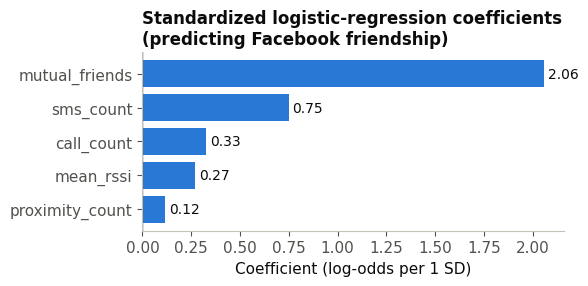

Strongest positive predictor of Facebook friendship: 'mutual_friends' (1 SD increase multiplies the odds of being friends by 7.83x).


In [17]:
order = coef_table.sort_values('coefficient')

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(order['feature'], order['coefficient'], color=BLUE)
ax.axvline(0, color="#52514e", linewidth=1)
for bar, value in zip(bars, order['coefficient']):
    ax.text(
        value + (0.02 if value >= 0 else -0.02), bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}", va='center', ha='left' if value >= 0 else 'right', fontsize=10,
    )
ax.set_title(
    "Standardized logistic-regression coefficients\n(predicting Facebook friendship)",
    loc='left', fontsize=12, fontweight='bold',
)
ax.set_xlabel("Coefficient (log-odds per 1 SD)")
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

top = coef_table.iloc[0]
print(f"Strongest positive predictor of Facebook friendship: '{top['feature']}' "
      f"(1 SD increase multiplies the odds of being friends by {top['odds_ratio']:.2f}x).")

Facebook-friendship graph: 800 nodes, 6,418 edges
Detected 8 communities, modularity = 0.384


,community_size
0,245
1,216
2,184
3,93
4,32
5,23
6,5
7,2


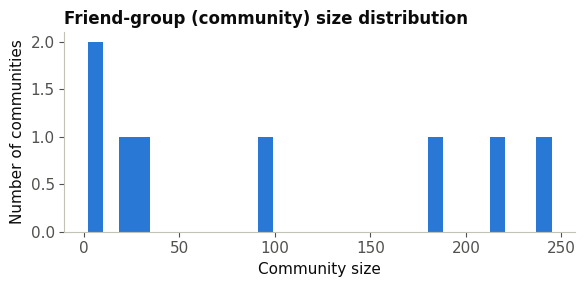

In [18]:
friend_graph = nx.Graph()
friend_graph.add_edges_from(fb_pairs.itertuples(index=False, name=None))

communities = list(nx.algorithms.community.greedy_modularity_communities(friend_graph))
modularity = nx.algorithms.community.modularity(friend_graph, communities)
community_sizes = pd.Series([len(c) for c in communities], name='community_size').sort_values(ascending=False)

print(f"Facebook-friendship graph: {friend_graph.number_of_nodes():,} nodes, {friend_graph.number_of_edges():,} edges")
print(f"Detected {len(communities)} communities, modularity = {modularity:.3f}")
display(community_sizes.head(10).reset_index(drop=True).to_frame())

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(community_sizes, bins=30, color=BLUE)
ax.set_title("Friend-group (community) size distribution", loc='left', fontsize=12, fontweight='bold')
ax.set_xlabel("Community size"); ax.set_ylabel("Number of communities")
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

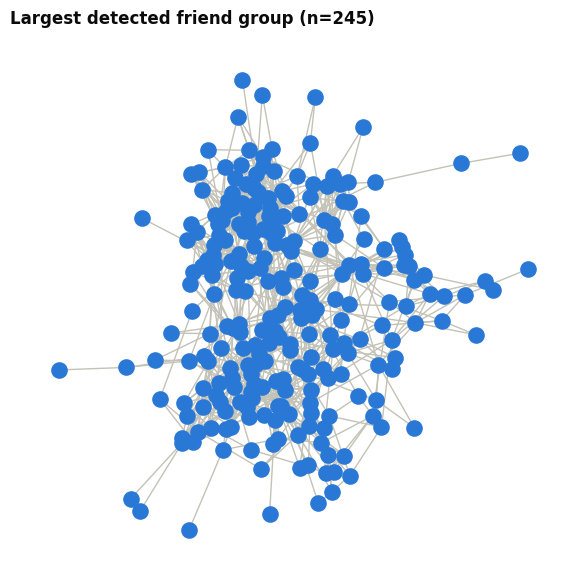

In [7]:
largest_community = max(communities, key=len)
subgraph = friend_graph.subgraph(largest_community)

fig, ax = plt.subplots(figsize=(6, 6))
pos = nx.spring_layout(subgraph, seed=42)
nx.draw_networkx(
    subgraph, pos=pos, node_color=BLUE, edge_color="#c3c2b7",
    node_size=120, font_size=6, with_labels=False, ax=ax,
)
ax.set_title(f"Largest detected friend group (n={len(largest_community)})", loc='left', fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Evolution of relationships over the 4-week study

We bucket every interaction (proximity, calls, texts) into
`elapsed_week = elapsed_day // 7` and compare network-wide weekly volume
across the four weeks — a sound comparison, since it aggregates over
hundreds of pairs and week-to-week noise averages out.

**A per-pair weekly trend is a different story.** Each pair has at most four
observations (one per week), leaving only 2 degrees of freedom for an OLS
slope — nowhere near enough to say a *particular* pair's relationship is
trending up or down; the standard error swamps the estimate. We show one
concrete example below to make that limitation tangible, then rely on the
network-level view for the actual conclusion about relationship evolution.

In [8]:
def elapsed_week(timestamp):
    return (timestamp // SECONDS_PER_DAY) // 7

weekly_calls = calls_data.assign(week=elapsed_week(calls_data['timestamp'])).groupby('week').size()
weekly_sms = sms_data.assign(week=elapsed_week(sms_data['timestamp'])).groupby('week').size()
weekly_bt = bt_valid.assign(week=elapsed_week(bt_valid['timestamp'])).groupby('week').size()

weekly_volume = pd.DataFrame({
    'Calls': weekly_calls, 'SMS': weekly_sms, 'Bluetooth proximity': weekly_bt
}).fillna(0)
display(weekly_volume)

,Calls,SMS,Bluetooth proximity
week,,,
0,737,6366,501666
1,1044,7071,716921
2,915,5595,607995
3,904,5301,599697


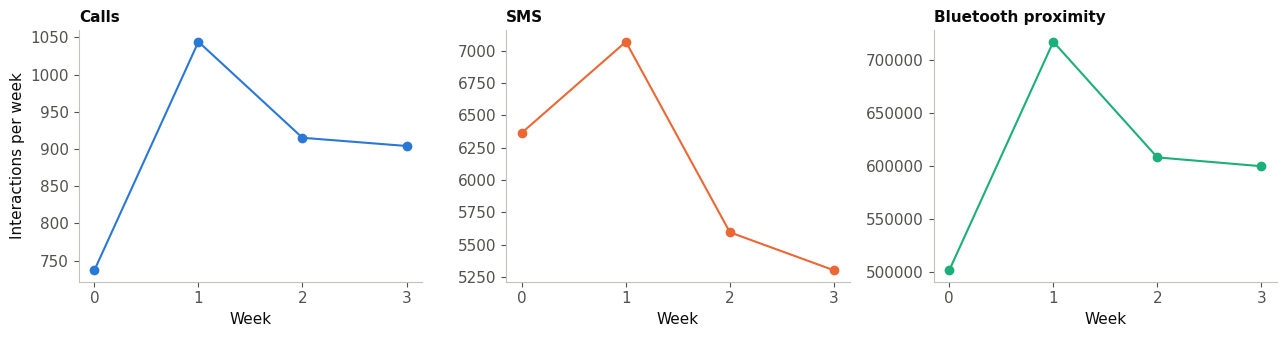

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, label, color in zip(axes, weekly_volume.columns, CATEGORICAL):
    ax.plot(weekly_volume.index, weekly_volume[label], marker='o', color=color)
    ax.set_title(label, loc='left', fontsize=11, fontweight='bold')
    ax.set_xlabel('Week')
    ax.set_xticks(weekly_volume.index)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
axes[0].set_ylabel('Interactions per week')
plt.tight_layout()
plt.show()

In [10]:
interaction_events = pd.concat([
    bt_pairs[pair_keys + ['timestamp']],
    sms_pairs[pair_keys + ['timestamp']],
    call_pairs[pair_keys + ['timestamp']],
], ignore_index=True)
interaction_events['week'] = elapsed_week(interaction_events['timestamp'])

pair_weekly_counts = interaction_events.groupby(pair_keys + ['week']).size().rename('count').reset_index()
busiest_pair = pair_weekly_counts.groupby(pair_keys)['count'].sum().idxmax()

example = (
    pair_weekly_counts[
        (pair_weekly_counts['user_a'] == busiest_pair[0]) & (pair_weekly_counts['user_b'] == busiest_pair[1])
    ]
    .set_index('week')['count']
    .reindex(range(4), fill_value=0)
)

slope, intercept, r_value, p_value, std_err = stats.linregress(example.index, example.values)
print(f"Example pair {busiest_pair} (highest total interaction volume): weekly counts = {example.values.tolist()}")
print(f"Per-pair OLS slope = {slope:.2f} +/- {std_err:.2f} interactions/week, p = {p_value:.3f}, n = 4 weeks")
print("With only 4 points, this slope's uncertainty is wide enough that we cannot distinguish an "
      "increasing relationship from a flat or declining one for this single pair -- exactly the "
      "'4 weeks is too short' concern. The network-level chart above is the trustworthy read.")

Example pair (np.int64(321), np.int64(322)) (highest total interaction volume): weekly counts = [1055, 1961, 1769, 1031]
Per-pair OLS slope = -26.40 +/- 262.85 interactions/week, p = 0.929, n = 4 weeks
With only 4 points, this slope's uncertainty is wide enough that we cannot distinguish an increasing relationship from a flat or declining one for this single pair -- exactly the '4 weeks is too short' concern. The network-level chart above is the trustworthy read.


## 3. Ranking participants from most to least isolated

**Model**: build one combined, weighted interaction graph — node =
participant, edge weight = `log1p(proximity_count + sms_count + call_count)`
between every pair that interacted at least once through any channel. We
then compute three centrality measures (degree, weighted degree, eigenvector
centrality) and combine them into a single **composite isolation score**:
the average percentile rank across the three (0 = least isolated, 1 = most
isolated).

A composite is used instead of any single raw count because the three
channels aren't equally available for everyone — someone who mostly
interacts by SMS shouldn't look "isolated" just because they made few calls.
Averaging percentile ranks puts each channel on the same scale and is robust
to any one channel being sparse for a given person.

In [11]:
pairwise_weighted = pairwise.copy()
pairwise_weighted['weight'] = np.log1p(
    pairwise_weighted['proximity_count'] + pairwise_weighted['sms_count'] + pairwise_weighted['call_count']
)

interaction_graph = nx.Graph()
interaction_graph.add_weighted_edges_from(
    pairwise_weighted[['user_a', 'user_b', 'weight']].itertuples(index=False, name=None)
)

degree = dict(interaction_graph.degree())
weighted_degree = dict(interaction_graph.degree(weight='weight'))
eigenvector = nx.eigenvector_centrality_numpy(interaction_graph, weight='weight')

centrality = pd.DataFrame({'degree': degree, 'weighted_degree': weighted_degree, 'eigenvector': eigenvector})
percentile_ranks = centrality.rank(pct=True)
centrality['isolation_score'] = 1 - percentile_ranks.mean(axis=1)
centrality = centrality.join(genders_data.set_index('user'), how='left').sort_values('isolation_score', ascending=False)

print(f"Interaction graph: {interaction_graph.number_of_nodes():,} nodes, {interaction_graph.number_of_edges():,} edges")

all_participants = genders_data['user']
zero_interaction_participants = all_participants[~all_participants.isin(centrality.index)]
if len(zero_interaction_participants):
    print(f"{len(zero_interaction_participants)} participants have zero recorded interactions in any "
          f"channel and are therefore maximally isolated (isolation_score = 1), but are absent from the "
          f"graph itself -- listed separately below rather than silently dropped.")
    display(zero_interaction_participants.to_frame(name='user'))

print("\nMost isolated participants (excluding the zero-interaction group above):")
display(centrality.head(10))
print("\nLeast isolated participants:")
display(centrality.tail(10).iloc[::-1])

Interaction graph: 838 nodes, 82,851 edges
7 participants have zero recorded interactions in any channel and are therefore maximally isolated (isolation_score = 1), but are absent from the graph itself -- listed separately below rather than silently dropped.


,user
487,511
680,716
688,724
691,727
751,803
767,822
786,847



Most isolated participants (excluding the zero-interaction group above):


,degree,weighted_degree,eigenvector,isolation_score,female
825,1,0.0,-1.275118e-17,0.974543,0.0
725,3,0.0,-1.476343e-17,0.969173,0.0
750,2,0.0,-7.660055e-18,0.968974,0.0
717,3,0.0,-1.004079e-17,0.967582,0.0
718,4,0.0,-2.182988e-17,0.966786,0.0
810,2,0.0,-4.170218e-18,0.965792,0.0
757,3,0.0,-7.221515e-18,0.965195,0.0
738,3,0.0,-5.449058e-18,0.964002,0.0
769,1,0.0,-1.438818e-18,0.963007,1.0
751,3,0.0,-3.342330e-18,0.960819,0.0



Least isolated participants:


,degree,weighted_degree,eigenvector,isolation_score,female
88,483,1237.752085,0.086829,0.000796,0.0
52,486,1194.669687,0.082720,0.002387,0.0
13,520,1172.628697,0.079728,0.003182,0.0
682,451,1177.005744,0.083635,0.003978,1.0
235,439,1232.044199,0.083094,0.004773,1.0
12,456,1088.616921,0.076332,0.007160,0.0
92,434,1059.633645,0.073485,0.011933,0.0
560,419,1102.383985,0.078418,0.013126,0.0
311,424,1061.202449,0.075649,0.013325,1.0
100,419,1099.149270,0.076595,0.013922,1.0


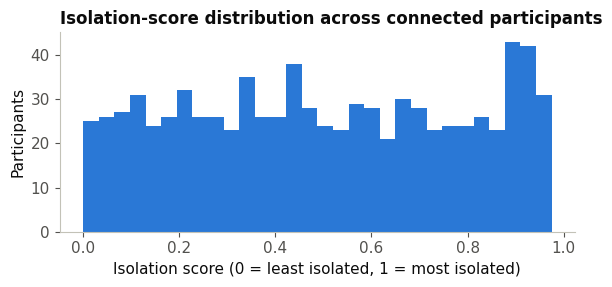

In [12]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(centrality['isolation_score'], bins=30, color=BLUE)
ax.set_title("Isolation-score distribution across connected participants", loc='left', fontsize=12, fontweight='bold')
ax.set_xlabel("Isolation score (0 = least isolated, 1 = most isolated)")
ax.set_ylabel("Participants")
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Does call duration trend upward over the study?

**Model**: ordinary least squares, `duration ~ timestamp`, fit on completed
calls only (`duration >= 0`; a missed call is a distinct phenomenon, not a
0-second call). Duration is heavily right-skewed (as already noted in
`eda_distributions.ipynb`), so we fit the regression both on raw seconds and
on `log1p(duration)` and compare — the log version is less dominated by a
handful of very long calls.

In [13]:
x = completed_calls['timestamp'].values.astype(float)
y_raw = completed_calls['duration'].values.astype(float)
y_log = np.log1p(y_raw)

slope_raw, intercept_raw, r_raw, p_raw, se_raw = stats.linregress(x, y_raw)
slope_log, intercept_log, r_log, p_log, se_log = stats.linregress(x, y_log)

trend_summary = pd.DataFrame({
    'target': ['duration (seconds)', 'log1p(duration)'],
    'slope_per_day': [slope_raw * SECONDS_PER_DAY, slope_log * SECONDS_PER_DAY],
    'r_squared': [r_raw ** 2, r_log ** 2],
    'p_value': [p_raw, p_log],
}).set_index('target')
display(trend_summary)

is_significant_upward = p_raw < 0.05 and slope_raw > 0
verdict = "an upward" if is_significant_upward else "no statistically significant"
print(f"Raw-duration regression shows {verdict} trend over the study "
      f"(slope = {slope_raw * SECONDS_PER_DAY:.4f} sec/day, p = {p_raw:.3g}, R^2 = {r_raw ** 2:.4f}).")

,slope_per_day,r_squared,p_value
target,,,
duration (seconds),-0.814939,0.001152,0.053645
log1p(duration),-0.012882,0.002904,0.002174


Raw-duration regression shows no statistically significant trend over the study (slope = -0.8149 sec/day, p = 0.0536, R^2 = 0.0012).


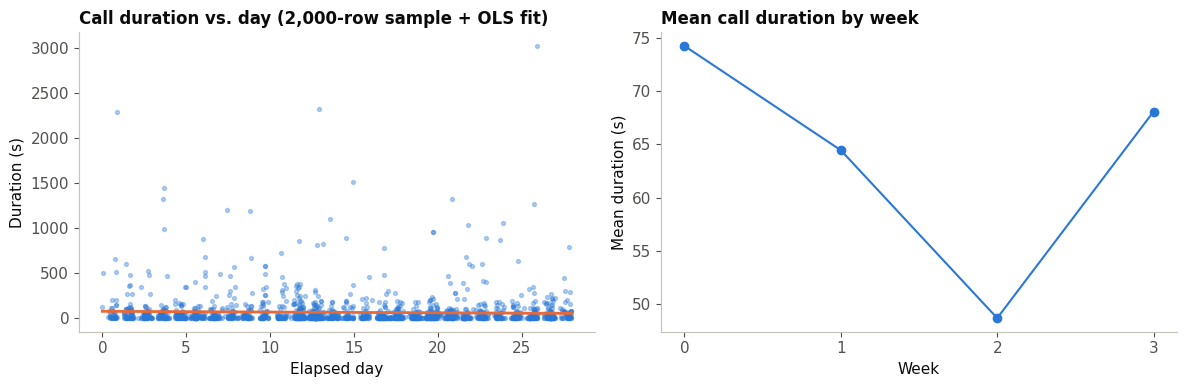

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sample = completed_calls.sample(n=min(2000, len(completed_calls)), random_state=42)
axes[0].scatter(sample['timestamp'] / SECONDS_PER_DAY, sample['duration'], s=8, alpha=0.35, color=BLUE)
trend_x = np.linspace(x.min(), x.max(), 100)
axes[0].plot(trend_x / SECONDS_PER_DAY, intercept_raw + slope_raw * trend_x, color=ORANGE, linewidth=2)
axes[0].set_title("Call duration vs. day (2,000-row sample + OLS fit)", loc='left', fontsize=12, fontweight='bold')
axes[0].set_xlabel("Elapsed day"); axes[0].set_ylabel("Duration (s)")

weekly_mean_duration = completed_calls.assign(
    week=elapsed_week(completed_calls['timestamp'])
).groupby('week')['duration'].mean()
axes[1].plot(weekly_mean_duration.index, weekly_mean_duration.values, marker='o', color=BLUE)
axes[1].set_title("Mean call duration by week", loc='left', fontsize=12, fontweight='bold')
axes[1].set_xlabel("Week"); axes[1].set_ylabel("Mean duration (s)")
axes[1].set_xticks(weekly_mean_duration.index)

for ax in axes:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## Summary

- **Friendship formation**: read the logistic-regression coefficients in
  section 1 — the feature with the largest positive coefficient is the
  strongest behavioral predictor of being Facebook friends in this sample.
  Compare the logistic ROC-AUC to the random-forest ROC-AUC to see whether a
  more flexible model finds meaningfully more signal than the interpretable
  one.
- **Friend groups**: the modularity score reported in section 1 indicates
  how cleanly the Facebook graph splits into communities (well above 0
  suggests real group structure rather than noise).
- **Evolution over 4 weeks**: only the network-level weekly view is reliable
  at this timescale — per-pair trend slopes are not statistically usable
  with just 4 points, as the worked example in section 2 shows directly.
- **Isolation ranking**: participants with zero recorded interactions in
  every channel are the most isolated by construction and are called out
  separately in section 3, since they never appear as nodes in the
  interaction graph.
- **Call duration trend**: read the slope and p-value in the section 4
  trend table — a p-value below 0.05 with a positive slope indicates a
  genuine (if possibly small) upward trend over the ~4-week window;
  otherwise the data does not support one.